# Comparisons to Other Studies

The goal here is to make plots that I can put side-by-side with figures from published studies to compare our results. I actually don't think this will take very long, so let's make it a second supplemental information section in the quals paper. You will need to do something similar anyway to write the discussion section, so might as well make it pretty now.

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import cmocean.cm as cmo
import cartopy.crs as ccrs

In [4]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [5]:
ds_pbar = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_var.nc')

In [6]:
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_cip_masking.nc')

In [7]:
ds_pbar_grid = ds_pbar_grid.assign_coords(LON_left = ds_pbar_grad.LON_left,LAT_left = ds_pbar_grad.LAT_left)
ds_pbar_grid = xr.merge([ds_pbar_grid, ds_pbar_grad.drop_vars({'DENSITY'})])

In [8]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

# Tracer Variance Production

## Ferrari & Polzin (2005), Broullon (2026)

In [9]:
FP = ds_pbar_grid.sel(LON=-29, LAT=26, method='nearest')
K_rho_FP = K_rho_p.sel(LON=-29, LAT=26, method='nearest')

Text(0.5, 1.0, 'Eddy Diffusivity \n Nearest NATRE Region')

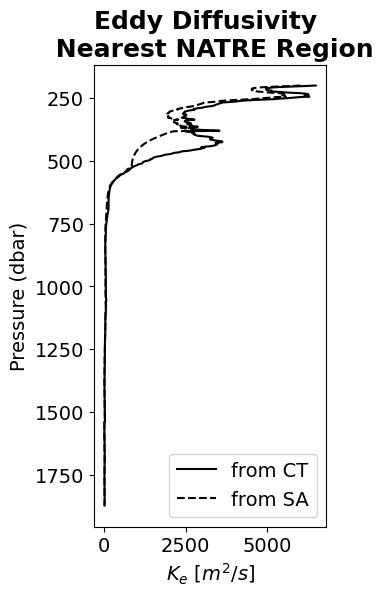

In [10]:
plt.figure(figsize=(3,6))
FP.K_e_CT.sel(PRESSURE_mean=slice(200,2000)).plot(y='PRESSURE_mean', label='from CT', color='k')
FP.K_e_SA.sel(PRESSURE_mean=slice(200,2000)).plot(y='PRESSURE_mean', label='from SA', linestyle='--', color='k')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('Pressure (dbar)')
plt.xlabel('$K_e$ [$m^2/s$]')
plt.title('Eddy Diffusivity \n Nearest NATRE Region')

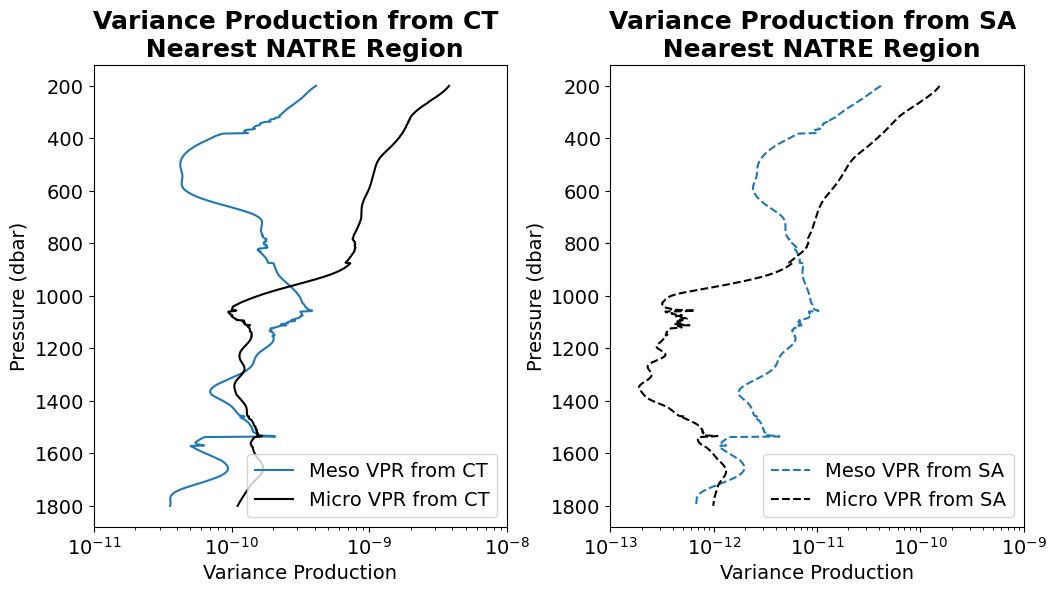

In [11]:
plt.figure(figsize=(12,6))

plt.subplot(121)
FP.CT_e_VPR.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', label='Meso VPR from CT')
FP.CT_m_VPR.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', label='Micro VPR from CT', color='k')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('Pressure (dbar)')
plt.xscale('log')
plt.xlim(1e-11, 1e-8)
plt.xlabel('Variance Production')
plt.title('Variance Production from CT \n Nearest NATRE Region')

plt.subplot(122)
FP.SA_e_VPR.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', label='Meso VPR from SA', linestyle='--', color='tab:blue')
FP.SA_m_VPR.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', label='Micro VPR from SA', linestyle='--', color='k')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('Pressure (dbar)')
plt.xscale('log')
plt.xlim(1e-13, 1e-9)
plt.xlabel('Variance Production')
plt.title('Variance Production from SA \n Nearest NATRE Region')

plt.subplots_adjust(wspace=0.25)

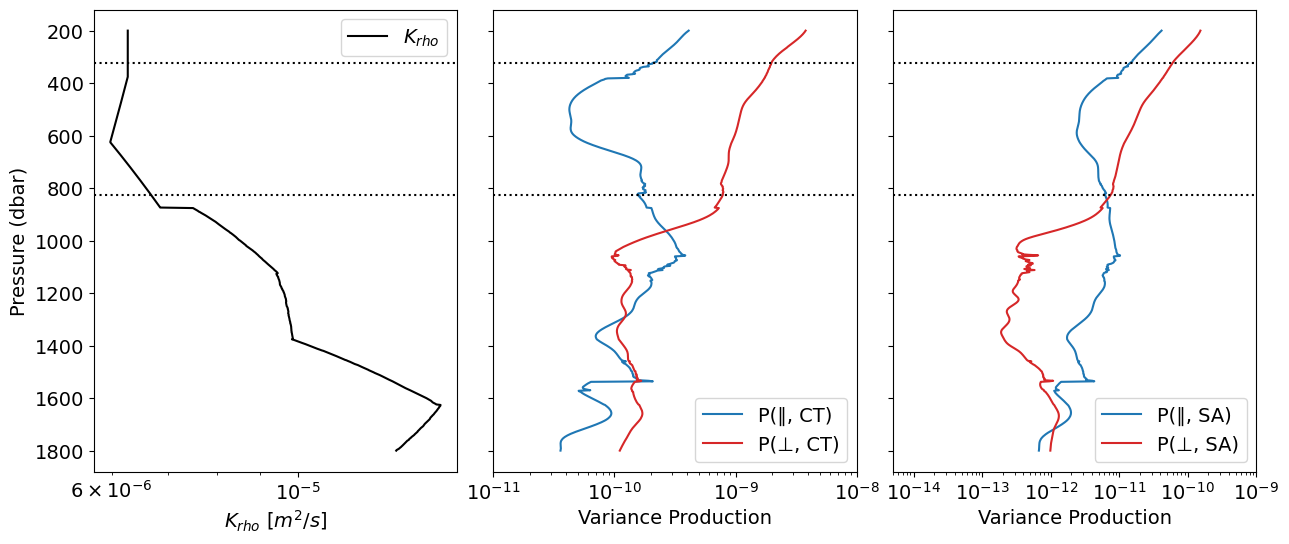

In [12]:
plt.figure(figsize=(15,6))

plt.subplot(131)
K_rho_FP.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', color='k', label='$K_{rho}$')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('Pressure (dbar)')
plt.xscale('log')
plt.xlabel('$K_{rho}$ [$m^2/s$]')
plt.title('')

plt.subplot(132)
FP.CT_e_VPR.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', label='P(∥, CT)', color='tab:blue')
FP.CT_m_VPR.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', label='P(⊥, CT)', color='tab:red')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('')
plt.gca().set_yticklabels([])
plt.xscale('log')
plt.xlim(1e-11, 1e-8)
plt.xlabel('Variance Production')
plt.title('')

plt.subplot(133)
FP.SA_e_VPR.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', label='P(∥, SA)', color='tab:blue')
FP.SA_m_VPR.sel(PRESSURE_mean=slice(200,1800)).plot(y='PRESSURE_mean', label='P(⊥, SA)', color='tab:red')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('')
plt.gca().set_yticklabels([])
plt.xscale('log')
plt.xlim(5e-15, 1e-9)
plt.xlabel('Variance Production')
plt.title('')

plt.subplots_adjust(wspace=0.1)

## Castro (2024)

In [13]:
WEB = ds_pbar_grid.sel(LON=-15, LAT=45, method='nearest')
IrmS = ds_pbar_grid.sel(LON=-35, LAT=60, method='nearest')
EGC = ds_pbar_grid.sel(LON=-32, LAT=65, method='nearest')
B = xr.concat([WEB, IrmS, EGC], dim="station").mean("station")

Text(0.5, 0, 'P(⊥, CT)')

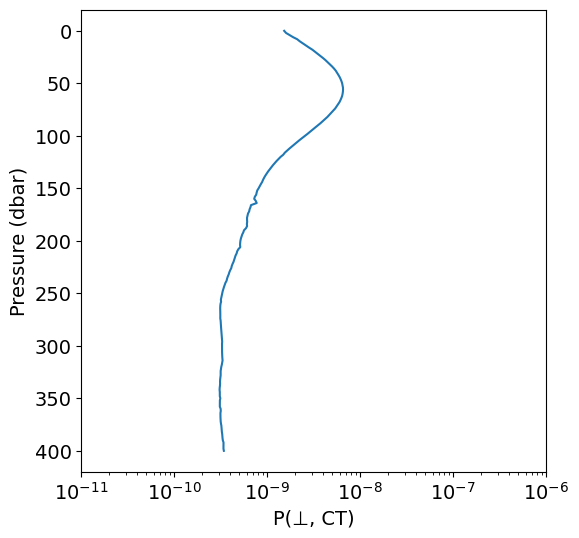

In [16]:
plt.figure(figsize=(6,6))
B.CT_m_VPR.sel(PRESSURE_mean=slice(0,400)).plot(y='PRESSURE_mean')
#B.CT_e_VPR.sel(PRESSURE_mean=slice(0,400)).plot(y='PRESSURE_mean')
plt.gca().invert_yaxis()
plt.ylabel('Pressure (dbar)')
plt.xscale('log')
plt.xlim(1e-11, 1e-6)
plt.xlabel('P(⊥, CT)')

Text(0.5, 0, 'P(⊥, SA)')

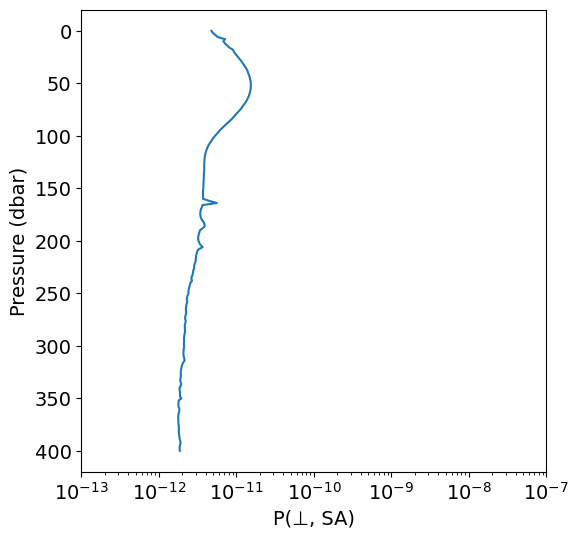

In [17]:
plt.figure(figsize=(6,6))
B.SA_m_VPR.sel(PRESSURE_mean=slice(0,400)).plot(y='PRESSURE_mean')
#B.SA_e_VPR.sel(PRESSURE_mean=slice(0,400)).plot(y='PRESSURE_mean')
plt.gca().invert_yaxis()
plt.ylabel('Pressure (dbar)')
plt.xscale('log')
plt.xlim(1e-13, 1e-7)
plt.xlabel('P(⊥, SA)')

# Eddy Diffusivity

## Cole (2015)

depth: 200 m
Comparison to Cole (2015)


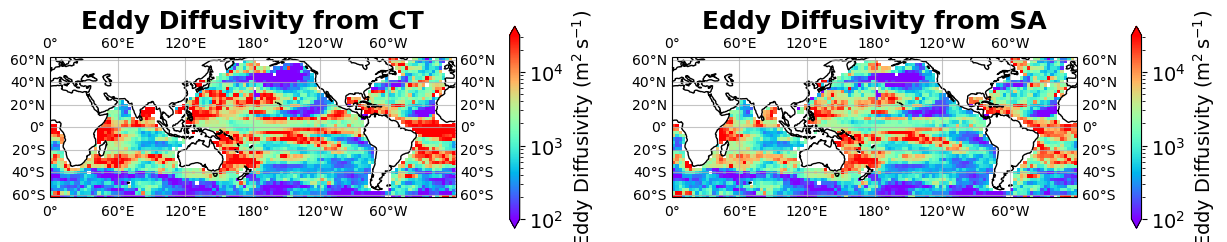

In [185]:
depth = 200
shrink, pad = 0.7, 0.1

# --- Configuration for each subplot ---
fields = [
    ("K_e_CT", 'rainbow', (10**(2), 10**(4.5)), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from CT"),
    ("K_e_SA", 'rainbow', (10**(2), 10**(4.5)), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from SA"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)

    # Title inside panel
    ax.set_title(title)
    ax.set_ylim(-62,62)

# --- Create figure and loop ---
fig, axes = plt.subplots(1, 2, figsize=(15, 3.75), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")
print("Comparison to Cole (2015)")

## Roach (2018)

depth: 1000 m
Comparison to Cole (2015)


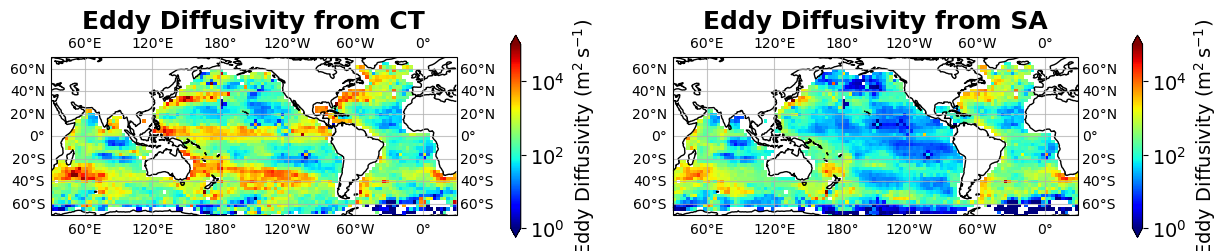

In [190]:
depth = 1000
shrink, pad = 0.7, 0.1

# --- Configuration for each subplot ---
fields = [
    ("K_e_CT", 'jet', (1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from CT"),
    ("K_e_SA", 'jet', (1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from SA"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)

    # Title inside panel
    ax.set_title(title)
    ax.set_ylim(-70,70)

# --- Create figure and loop ---
fig, axes = plt.subplots(1, 2, figsize=(15, 3.75), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-150)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")
print("Comparison to Cole (2015)")

## Sevellec (2025)

depth: 1000 m
Comparison to Sevellec (2025)


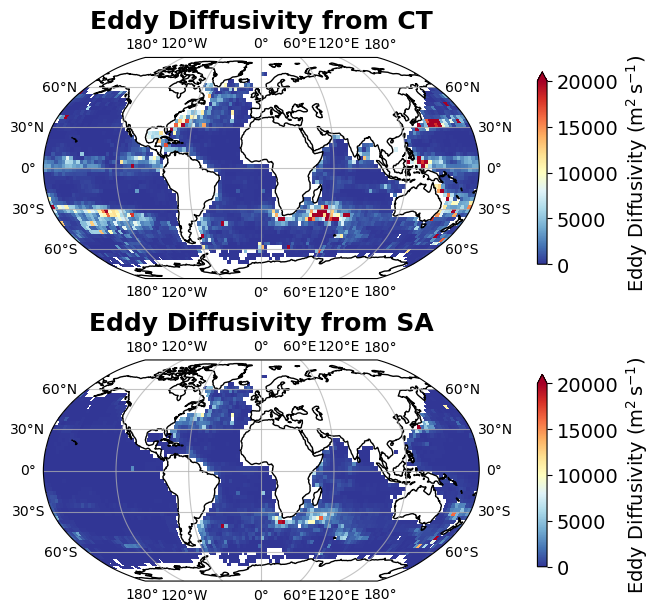

In [206]:
depth = 1000
shrink, pad = 0.7, 0.1

# --- Configuration for each subplot ---
fields = [
    ("K_e_CT", 'RdYlBu_r', (0*1e3, 20*1e3), "lin", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from CT"),
    ("K_e_SA", 'RdYlBu_r', (0*1e3, 20*1e3), "lin", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from SA"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)

    # Title inside panel
    ax.set_title(title)

# --- Create figure and loop ---
fig, axes = plt.subplots(2, 1, figsize=(7.5, 7.5), subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")
print("Comparison to Sevellec (2025)")

# Eddy Fluxes

## Jakes (2025)

In [102]:
J = ds_pbar_grid.sel(LAT=slice(-70, -35))
K_rho_J = K_rho_p.sel(LAT=slice(-70, -35))

In [ ]:
EHF = J.CT_e_VPR

In [134]:
EHF = J.K_e_CT * np.sqrt(J.dCT_m_dx**2 + J.dCT_m_dy**2) * J.DENSITY * J.Cp
EHF_av = (EHF.sel(PRESSURE_mean=slice(0,1000)).mean('PRESSURE_mean')/1000)

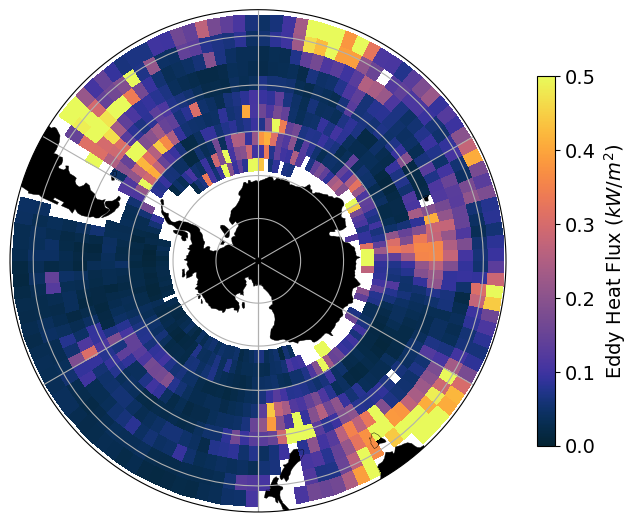

In [142]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import cmocean.cm as cmo

# EHF_av is (PRESSURE_mean averaged) → shape (LON, LAT) or (LAT, LON)
EHF2 = EHF_av.transpose('LAT', 'LON')

proj = ccrs.SouthPolarStereo()

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Geographic extent 30°S–90°S
ax.set_extent([-180, 180, -90, -35], crs=ccrs.PlateCarree())

# Circular boundary
theta = np.linspace(0, 2*np.pi, 200)
circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)
ax.set_boundary(circle, transform=ax.transAxes)

# Continents in black
ax.add_feature(cfeature.LAND, facecolor='black')
ax.add_feature(cfeature.COASTLINE, linewidth=0.3, edgecolor='black')

# No gridlines
ax.gridlines(draw_labels=False)

# Plot the averaged field
pcm = ax.pcolormesh(
    EHF2['LON'],
    EHF2['LAT'],
    EHF2,
    transform=ccrs.PlateCarree(),
    cmap=cmo.thermal,
    shading='auto'
)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax, shrink=0.6)
pcm.set_clim(0, 0.5)
cbar.set_label("Eddy Heat Flux ($kW/m^2$)")

plt.show()

## Sun (2018)

In [160]:
# ---------------------------------------------------------
# Compute zonal metric Δx
# ---------------------------------------------------------
R = 6371e3
dlon = np.deg2rad(float(ds_pbar_grid.LON[1] - ds_pbar_grid.LON[0]))
lat_rad = np.deg2rad(ds_pbar_grid.LAT)

dx = R * np.cos(lat_rad) * dlon
dx_da = xr.DataArray(dx, dims=['LAT'])
dx_3d = dx_da.broadcast_like(ds_pbar_grid.F_heat_y)

# ---------------------------------------------------------
# Add constant Δz (m)
# ---------------------------------------------------------
delta_z = 2.0   # choose your constant vertical thickness (meters)

# ---------------------------------------------------------
# Compute basin-specific meridional heat transport
# ---------------------------------------------------------
Fy_dx_dz = ds_pbar_grad.F_heat_y.sel(PRESSURE_mean=slice(100,2000)) * dx_3d * delta_z

transport_atl    = Fy_dx_dz.where(ds_pbar_grad.basin==1).sum(dim=['PRESSURE_mean', 'LON'])
transport_pac    = Fy_dx_dz.where(ds_pbar_grad.basin==2).sum(dim=['PRESSURE_mean', 'LON'])
transport_ind    = Fy_dx_dz.where(ds_pbar_grad.basin==3).sum(dim=['PRESSURE_mean', 'LON'])
transport_sou    = Fy_dx_dz.where(ds_pbar_grad.basin==10).sum(dim=['PRESSURE_mean', 'LON'])
transport_art    = Fy_dx_dz.where(ds_pbar_grad.basin==11).sum(dim=['PRESSURE_mean', 'LON'])
transport_global = Fy_dx_dz.where(ds_pbar_grad.basin.isin([1, 2, 3, 10, 11])).sum(dim=['PRESSURE_mean', 'LON'])

In [161]:
mask = (lat > -10) & (lat < 10)

transport_global_masked = transport_global.copy()
transport_global_masked[mask] = np.nan

transport_pac_masked = transport_pac.copy()
transport_pac_masked[mask] = np.nan

transport_atl_masked = transport_atl.copy()
transport_atl_masked[mask] = np.nan

transport_ind_masked = transport_ind.copy()
transport_ind_masked[mask] = np.nan


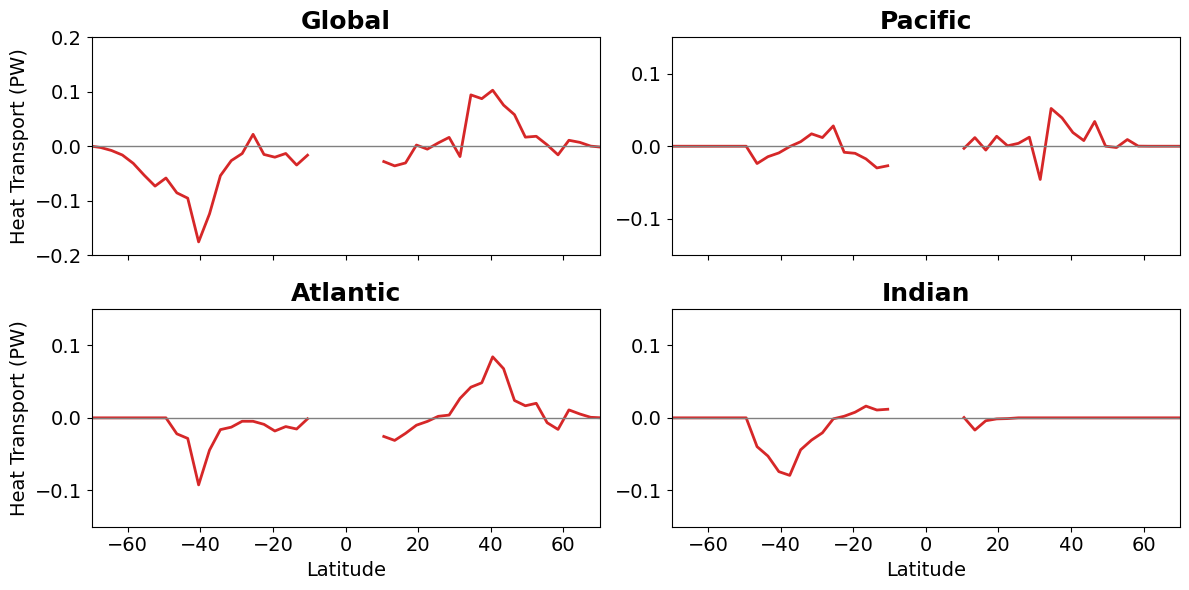

In [162]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

lat = ds_pbar_grid.LAT

# -------------------------
# Upper left: Global
# -------------------------
ax = axs[0, 0]
ax.plot(lat, transport_global_masked / 1e15, color='tab:red', linewidth=2)
ax.set_title('Global')
ax.set_xlim([-70, 70])
ax.set_ylim([-0.2, 0.2])
ax.axhline(0, color='gray', linewidth=1)
ax.set_ylabel('Heat Transport (PW)')

# -------------------------
# Upper right: Pacific
# -------------------------
ax = axs[0, 1]
ax.plot(lat, transport_pac_masked / 1e15, color='tab:red', linewidth=2)
ax.set_title('Pacific')
ax.set_xlim([-70, 70])
ax.set_ylim([-0.15, 0.15])
ax.axhline(0, color='gray', linewidth=1)

# -------------------------
# Lower left: Atlantic
# -------------------------
ax = axs[1, 0]
ax.plot(lat, transport_atl_masked / 1e15, color='tab:red', linewidth=2)
ax.set_title('Atlantic')
ax.set_xlim([-70, 70])
ax.set_ylim([-0.15, 0.15])
ax.axhline(0, color='gray', linewidth=1)
ax.set_xlabel('Latitude')
ax.set_ylabel('Heat Transport (PW)')

# -------------------------
# Lower right: Indian
# -------------------------
ax = axs[1, 1]
ax.plot(lat, transport_ind_masked / 1e15, color='tab:red', linewidth=2)
ax.set_title('Indian')
ax.set_xlim([-70, 70])
ax.set_ylim([-0.15, 0.15])
ax.axhline(0, color='gray', linewidth=1)
ax.set_xlabel('Latitude')

# Layout and save
plt.tight_layout()
plt.savefig('quals_paper/discussion/1_heat_transport_4panel.png',
            dpi=300, bbox_inches='tight')
plt.show()